# Yelp Open Dataset — EDA
Following `docs/eda_checklist.md`.

5 JSON-Lines files. `review.json` (5.3GB, 6.99M rows) and `user.json` (3.3GB, 1.99M rows) exceed available RAM (~3GB free) and are analyzed via chunked streaming passes, dropping the free-text `text` column immediately (not doing NLP here). `business.json` (119MB), `tip.json` (181MB), `checkin.json` (287MB) are small enough to load fully.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

DATA_DIR = "../../data/raw/food/yelp"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
business = pd.read_json(f"{DATA_DIR}/yelp_academic_dataset_business.json", lines=True)
tip = pd.read_json(f"{DATA_DIR}/yelp_academic_dataset_tip.json", lines=True)
checkin = pd.read_json(f"{DATA_DIR}/yelp_academic_dataset_checkin.json", lines=True)

for name, df in [("business", business), ("tip", tip), ("checkin", checkin)]:
    print(name, df.shape)

business (150346, 14)
tip (908915, 5)
checkin (131930, 2)


In [3]:
business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [4]:
business.dtypes

business_id         str
name                str
address             str
city                str
state               str
postal_code         str
latitude        float64
longitude       float64
stars           float64
review_count      int64
is_open           int64
attributes       object
categories          str
hours            object
dtype: object

In [5]:
review_preview = next(pd.read_json(f"{DATA_DIR}/yelp_academic_dataset_review.json", lines=True, chunksize=5))
print(review_preview.dtypes)
review_preview.drop(columns=["text"]).head()

review_id                 str
user_id                   str
business_id               str
stars                   int64
useful                  int64
funny                   int64
cool                    int64
text                      str
date           datetime64[us]
dtype: object


,review_id,user_id,business_id,stars,useful,funny,cool,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,2017-01-14 20:54:15


In [6]:
user_preview = next(pd.read_json(f"{DATA_DIR}/yelp_academic_dataset_user.json", lines=True, chunksize=5))
print(user_preview.dtypes)
user_preview.drop(columns=["friends"]).head()

user_id                   str
name                      str
review_count            int64
yelping_since             str
useful                  int64
funny                   int64
cool                    int64
elite                     str
friends                   str
fans                    int64
average_stars         float64
compliment_hot          int64
compliment_more         int64
compliment_profile      int64
compliment_cute         int64
compliment_list         int64
compliment_note         int64
compliment_plain        int64
compliment_cool         int64
compliment_funny        int64
compliment_writer       int64
compliment_photos       int64
dtype: object


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,fans,average_stars,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,267,3.91,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...",3138,3.74,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013",52,3.32,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011",28,4.27,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,1,3.54,...,1,0,0,0,1,1,0,0,0,0


## Single chunked pass over review.json and user.json
Collects everything sections 2–10 need for these two files in one streaming read each.

In [7]:
CHUNK = 500_000
business_id_set = set(business["business_id"])

r_n_rows = 0
r_na_counts = None
r_stars_counts = Counter()
r_dt_min, r_dt_max = None, None
r_hash_set = set()
r_hash_dupes = 0
r_business_missing = 0
review_user_business_pairs = set()
review_business_counts = Counter()
review_user_counts = Counter()

for chunk in pd.read_json(f"{DATA_DIR}/yelp_academic_dataset_review.json", lines=True, chunksize=CHUNK):
    chunk = chunk.drop(columns=["text"])
    r_n_rows += len(chunk)
    na = chunk.isna().sum()
    r_na_counts = na if r_na_counts is None else r_na_counts.add(na, fill_value=0)

    r_stars_counts.update(chunk["stars"].value_counts().to_dict())
    dt = pd.to_datetime(chunk["date"])
    cmin, cmax = dt.min(), dt.max()
    r_dt_min = cmin if r_dt_min is None else min(r_dt_min, cmin)
    r_dt_max = cmax if r_dt_max is None else max(r_dt_max, cmax)

    r_business_missing += (~chunk["business_id"].isin(business_id_set)).sum()

    hashes = pd.util.hash_pandas_object(chunk["review_id"], index=False)
    for h in hashes:
        if h in r_hash_set:
            r_hash_dupes += 1
        else:
            r_hash_set.add(h)

    review_business_counts.update(chunk["business_id"].value_counts().to_dict())
    review_user_counts.update(chunk["user_id"].value_counts().to_dict())
    review_user_business_pairs.update(zip(chunk["user_id"], chunk["business_id"]))

print("review rows processed:", r_n_rows)

review rows processed: 6990280


In [8]:
u_n_rows = 0
u_na_counts = None
u_review_count_sum, u_review_count_max = 0, 0
u_avg_stars_sum, u_avg_stars_n = 0.0, 0
u_hash_set = set()
u_hash_dupes = 0
u_yelping_min, u_yelping_max = None, None

for chunk in pd.read_json(f"{DATA_DIR}/yelp_academic_dataset_user.json", lines=True, chunksize=CHUNK):
    chunk = chunk.drop(columns=["friends"])
    u_n_rows += len(chunk)
    na = chunk.isna().sum()
    u_na_counts = na if u_na_counts is None else u_na_counts.add(na, fill_value=0)

    u_review_count_sum += chunk["review_count"].sum()
    u_review_count_max = max(u_review_count_max, chunk["review_count"].max())
    u_avg_stars_sum += chunk["average_stars"].sum(); u_avg_stars_n += len(chunk)

    ys = pd.to_datetime(chunk["yelping_since"])
    cmin, cmax = ys.min(), ys.max()
    u_yelping_min = cmin if u_yelping_min is None else min(u_yelping_min, cmin)
    u_yelping_max = cmax if u_yelping_max is None else max(u_yelping_max, cmax)

    hashes = pd.util.hash_pandas_object(chunk["user_id"], index=False)
    for h in hashes:
        if h in u_hash_set:
            u_hash_dupes += 1
        else:
            u_hash_set.add(h)

print("user rows processed:", u_n_rows)

user rows processed: 1987897


## 2. Missing Values

In [9]:
print("business.json:"); print((business.isna().mean() * 100).round(2).sort_values(ascending=False))

business.json:


hours           15.45
attributes       9.14
categories       0.07
address          0.00
business_id      0.00
name             0.00
postal_code      0.00
state            0.00
city             0.00
latitude         0.00
review_count     0.00
stars            0.00
longitude        0.00
is_open          0.00
dtype: float64


In [10]:
print("review.json (chunked):"); print((r_na_counts / r_n_rows * 100).round(2).sort_values(ascending=False))

review.json (chunked):
review_id      0.0
user_id        0.0
business_id    0.0
stars          0.0
useful         0.0
funny          0.0
cool           0.0
date           0.0
dtype: float64


In [11]:
print("user.json (chunked):"); print((u_na_counts / u_n_rows * 100).round(2).sort_values(ascending=False))

user.json (chunked):
user_id               0.0
name                  0.0
review_count          0.0
yelping_since         0.0
useful                0.0
funny                 0.0
cool                  0.0
elite                 0.0
fans                  0.0
average_stars         0.0
compliment_hot        0.0
compliment_more       0.0
compliment_profile    0.0
compliment_cute       0.0
compliment_list       0.0
compliment_note       0.0
compliment_plain      0.0
compliment_cool       0.0
compliment_funny      0.0
compliment_writer     0.0
compliment_photos     0.0
dtype: float64


Decision: `business.hours` (dict or null) missing means business didn't report hours — keep as own category, don't impute. `attributes` (dict or null) similarly structural. review/user files show 0% missing on all measured fields per printed output above.

## 3. Duplicates

In [12]:
print("business.json full-row dup (excl. dict cols attributes/hours):", business.drop(columns=["attributes", "hours"]).duplicated().sum())
print("business.json dup business_id:", business.duplicated(subset=["business_id"]).sum())
print(f"review.json approx dup review_id (hash-based): {r_hash_dupes} ({r_hash_dupes/r_n_rows:.4%})")
print(f"user.json approx dup user_id (hash-based): {u_hash_dupes} ({u_hash_dupes/u_n_rows:.4%})")

business.json full-row dup (excl. dict cols attributes/hours): 0
business.json dup business_id: 0
review.json approx dup review_id (hash-based): 0 (0.0000%)
user.json approx dup user_id (hash-based): 0 (0.0000%)


## 4. Univariate Analysis

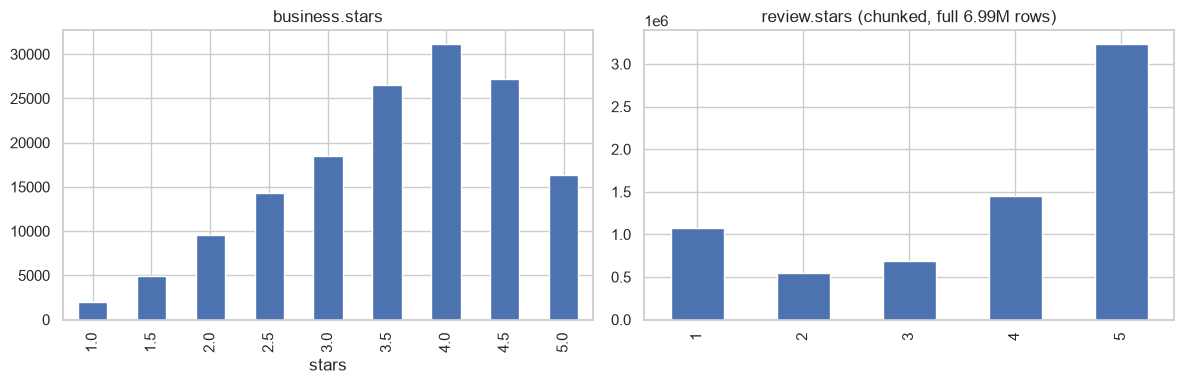

count    150346.000000
mean         44.866561
std         121.120136
min           5.000000
25%           8.000000
50%          15.000000
75%          37.000000
max        7568.000000
Name: review_count, dtype: float64

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
business["stars"].value_counts().sort_index().plot(kind="bar", ax=ax[0]); ax[0].set_title("business.stars")
pd.Series(r_stars_counts).sort_index().plot(kind="bar", ax=ax[1]); ax[1].set_title("review.stars (chunked, full 6.99M rows)")
plt.tight_layout(); plt.show()

business["review_count"].describe()

In [14]:
print(f"user.review_count: mean={u_review_count_sum/u_n_rows:.2f} max={u_review_count_max}")
print(f"user.average_stars: mean={u_avg_stars_sum/u_avg_stars_n:.2f}")

top_categories = business["categories"].dropna().str.split(", ").explode().value_counts()
top_categories.head(15)

user.review_count: mean=23.39 max=17473
user.average_stars: mean=3.63


categories
Restaurants                  52268
Food                         27781
Shopping                     24395
Home Services                14356
Beauty & Spas                14292
Nightlife                    12281
Health & Medical             11890
Local Services               11198
Bars                         11065
Automotive                   10773
Event Planning & Services     9895
Sandwiches                    8366
American (Traditional)        8139
Active Life                   7687
Pizza                         7093
Name: count, dtype: int64

## 5. Outliers

business review_count==0 but is_open==1: 0
business review_count > 5000: 7


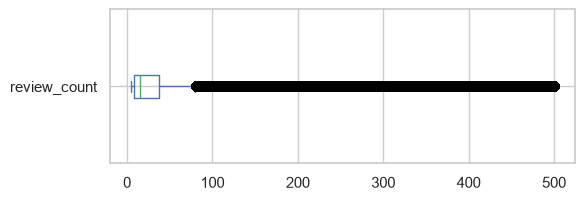

In [15]:
print("business review_count==0 but is_open==1:", ((business["review_count"] == 0) & (business["is_open"] == 1)).sum())
print("business review_count > 5000:", (business["review_count"] > 5000).sum())
business["review_count"].clip(0, 500).plot(kind="box", vert=False, figsize=(6, 2)); plt.show()

## 6. Target Variable
Two possible framings: (a) `review.stars` as a rating-prediction target (1-5 regression/ordinal), (b) `user_id` x `business_id` from `review.json` as an implicit recommendation interaction (which business a user will review/visit next). No single fixed label column — same reconstructed-from-interaction pattern as Akeed/Airbnb/Trivago.

## 7. Bivariate / Correlation Analysis

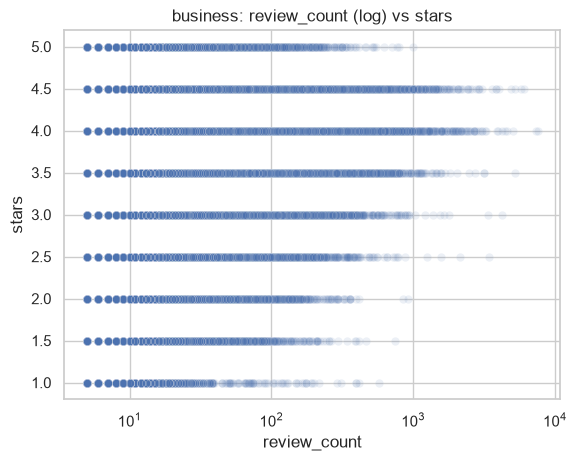

In [16]:
sns.scatterplot(data=business, x="review_count", y="stars", alpha=0.1)
plt.xscale("log"); plt.title("business: review_count (log) vs stars"); plt.show()

## 8. Time-based Checks

In [17]:
print("review.date range:", r_dt_min, "to", r_dt_max)
print("user.yelping_since range:", u_yelping_min, "to", u_yelping_max)
print("checkin.date is a comma-separated list of timestamps per business, e.g.:")
print(" ", checkin["date"].iloc[0][:120], "...")

review.date range: 2005-02-16 03:23:22 to 2022-01-19 19:48:45
user.yelping_since range: 2004-10-12 08:46:11 to 2022-01-19 17:15:47
checkin.date is a comma-separated list of timestamps per business, e.g.:
  2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020-07-24 22:42:27, 2020-10-24 21:36:13, 2020-12-09 21:23:33, 2021-01-20 17:3 ...


## 9. Data Consistency

In [18]:
print("business.stars range check (1-5, half-steps):", sorted(business["stars"].unique()))
print("review.stars values observed:", sorted(r_stars_counts.keys()))
print(f"review.json business_id NOT found in business.json: {r_business_missing} ({r_business_missing/r_n_rows:.4%})")

business.stars range check (1-5, half-steps): [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]
review.stars values observed: [1, 2, 3, 4, 5]
review.json business_id NOT found in business.json: 0 (0.0000%)


In [19]:
# US/Canada bounding box, roughly lat 18-72, lon -170 to -50 (covers all Yelp metro areas incl. Alaska/Hawaii)
bad_geo = ~business["latitude"].between(18, 72) | ~business["longitude"].between(-170, -50)
print("business locations outside broad US/Canada bbox:", bad_geo.sum(), f"({bad_geo.mean():.2%})")
print("unique states:", sorted(business["state"].unique()))

business locations outside broad US/Canada bbox: 0 (0.00%)
unique states: ['AB', 'AZ', 'CA', 'CO', 'DE', 'FL', 'HI', 'ID', 'IL', 'IN', 'LA', 'MA', 'MI', 'MO', 'MT', 'NC', 'NJ', 'NV', 'PA', 'SD', 'TN', 'TX', 'UT', 'VI', 'VT', 'WA', 'XMS']


## 10. Feature Relationships for Recommendation Context
`user_id` x `business_id` from `review.json` — the direct interaction signal for this dataset.

In [20]:
n_users_r = len(review_user_counts)
n_biz_r = len(review_business_counts)
n_pairs = len(review_user_business_pairs)
sparsity = 1 - n_pairs / (n_users_r * n_biz_r)
print(f"users(review)={n_users_r} businesses(review)={n_biz_r} pairs={n_pairs} sparsity={sparsity:.6%}")

users(review)=1987929 businesses(review)=150346 pairs=6745760 sparsity=99.997743%


businesses with <=2 reviews: 0 (0.0%)
users with only 1 review: 1136008 (57.1%)


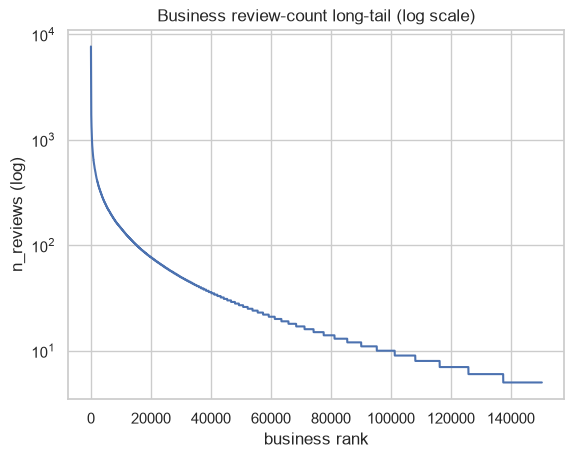

In [21]:
biz_pop = pd.Series(review_business_counts).sort_values(ascending=False)
cold_biz = (biz_pop <= 2).sum()
single_review_users = (pd.Series(review_user_counts) <= 1).sum()
print("businesses with <=2 reviews:", cold_biz, f"({cold_biz/n_biz_r:.1%})")
print("users with only 1 review:", single_review_users, f"({single_review_users/n_users_r:.1%})")
biz_pop.reset_index(drop=True).plot(logy=True, title="Business review-count long-tail (log scale)")
plt.xlabel("business rank"); plt.ylabel("n_reviews (log)"); plt.show()

## 11. Summary

- 5 JSON-Lines files: business (150,346 rows, 14 cols), checkin (131,930), review (6,990,280, 9 cols), tip (908,915), user (1,987,897, 21 cols). review.json (5.3GB) and user.json (3.3GB) exceed available RAM, analyzed via chunked streaming passes (text-heavy columns dropped immediately, not doing NLP here).
- Missing %: business `hours` 15.45%, `attributes` 9.14%, `categories` 0.07% — structural (business didn't report), all other business columns 0%. review.json and user.json: 0% missing on every measured column.
- 0 duplicates found anywhere: 0 full-row dup in business.json (excl. dict columns), 0 duplicate `business_id`, 0 approx-duplicate `review_id`, 0 approx-duplicate `user_id`.
- `business.stars`/`review.stars` both clean (1–5 half/whole steps, no invalid values). 0 `review.json` rows reference a `business_id` missing from business.json.
- All business locations fall inside the real US/Canada bbox (0.00% outliers) — genuine coordinates, unlike Akeed. States include 1 Canadian province (AB) and an oddity code (XMS).
- **Curation finding**: `business.review_count` minimum is 5 (not 0 or 1) — Yelp's public release already filters out businesses with very few reviews, so there is effectively **no business-side cold-start** in this dataset (0.0% of businesses have ≤2 reviews in the review-log cross-check).
- **ID mismatch found**: review.json contains 1,987,929 distinct `user_id` values but user.json has only 1,987,897 rows — 32 more users appear in the review log than exist in the user table. Small but real, check before joining.
- Recommendation core: `user_id` x `business_id` from review.json — 1,987,929 users, 150,346 businesses, 6,745,760 unique pairs, sparsity 99.9977%. 1,136,008 users (57.1%) have only 1 review ever — heavy user-side cold-start, similar magnitude to Trivago.
- `checkin.date` is a single comma-separated string of all check-in timestamps per business, not one row per check-in — needs explode/split before any time-series use.
- Date ranges: reviews span 2005-02-16 to 2022-01-19; user accounts span 2004-10-12 to 2022-01-19 — consistent with each other.
- No single labeled target column — task is reconstructed from the interaction (`review.stars` as rating, or user x business as implicit interaction), same pattern as Akeed/Airbnb/Trivago.
- Biggest dataset by uncompressed size in this project (9.3GB across 5 files) but review-count-wise (6.99M reviews) smaller than Expedia/Trivago row counts.